# 위험중립형 전략 — 분기 종목 교체(Rotation) 포트폴리오 백테스팅

| 항목 | 내용 |
|------|------|
| 전략 | `neutral` — 위험중립형 (ADX 25, 분할 진입 40%→70%) |
| 투자금액 | 1,000만원 |
| 기간 | 2018 ~ 2025 |
| Rotation | 분기별 종목 교체 계획 (RotationPlan) 적용 |
| 비교 | Rotation 적용 vs 미적용 자산 곡선 비교 |
| 방법 | Walk-Forward (IS 12개월 학습 → OOS 3개월 적용) |

**실행 순서**: 셀을 위에서 아래로 순서대로 실행

### Rotation 전략이란?

분기 검토 결과 편출이 확정된 종목을 **sell-only 모드**로 전환한다.

| 상태 | 매수 신호 | 매도 신호 |
|------|---------|---------|
| 편출 확정 종목 | **차단** (신규 매수 불가) | 정상 동작 (기존 포지션 청산 대기) |
| 신규 편입 종목 | 정상 동작 | 정상 동작 |
| 기존 유지 종목 | 정상 동작 | 정상 동작 |

- `deadline_days` 거래일 이내 **강제 청산** 보장
- 신규 편입 종목은 전체 유니버스에 포함되어 자연스럽게 신호 발생 시 매수

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import koreanize_matplotlib

from stock_system.profiles import get_profile
from stock_system.rotation import RotationPlan                    # ← NEW
from stock_system.backtest.engine import run_walk_forward, run_bh_portfolio
from stock_system.backtest.adapter import extract
from stock_system.metrics.calc import calc_metrics
from stock_system.metrics.report import build_metrics_table, build_period_stats_table
from stock_system.plots.performance import (
    plot_equity_curves,
    plot_weight_heatmap,
    plot_contribution,
    plot_diversification,
    plot_yearly_returns,
    plot_yearly_pnl,
    plot_mdd_comparison,
    plot_quarterly_returns,
    plot_monthly_heatmap,
    plot_per_stock_equity_curves,
    plot_yearly_stock_etf,
)
from stock_system.plots.strategy import plot_regime

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 기본 설정

In [2]:
PROFILE_NAME    = 'neutral'
INITIAL_CAPITAL = 10_000_000   # 1000만원
START_DATE      = '2018-01-01'
END_DATE        = '2025-12-31'

profile = get_profile(PROFILE_NAME)

print(f'전략        : {PROFILE_NAME} (위험중립형)')
print(f'초기 자본   : {INITIAL_CAPITAL:,}원  ({INITIAL_CAPITAL // 10_000}만원)')
print(f'백테스팅 기간: {START_DATE} ~ {END_DATE}')
print()
print(f'  ADX 임계값    : {profile.ADX_THRESHOLD}')
print(f'  ADX 횡보 기준 : {profile.ADX_SIDEWAYS}')
print(f'  1차 진입 비중 : {profile.ENTRY1_SIZE:.0%}')
print(f'  2차 진입 비중 : {profile.ENTRY2_SIZE:.0%}')
print(f'  횡보 진입 비중: {profile.ENTRY_RANGE_SIZE:.0%}')
print(f'  수수료        : {profile.FEES:.2%}')
print(f'  슬리피지      : {profile.SLIPPAGE:.2%}')
print(f'  WF 학습 기간  : {profile.WF_TRAIN_MONTHS}개월')
print(f'  WF 검증 기간  : {profile.WF_TEST_MONTHS}개월')

전략        : neutral (위험중립형)
초기 자본   : 10,000,000원  (1000만원)
백테스팅 기간: 2018-01-01 ~ 2025-12-31

  ADX 임계값    : 25.0
  ADX 횡보 기준 : 20.0
  1차 진입 비중 : 40%
  2차 진입 비중 : 70%
  횡보 진입 비중: 30%
  수수료        : 0.15%
  슬리피지      : 0.10%
  WF 학습 기간  : 12개월
  WF 검증 기간  : 3개월


---
## 2. 포트폴리오 종목 구성 + 교체 후보

기본 5종목에 교체 후보를 추가한 전체 유니버스로 데이터를 수집한다.
편출 종목의 빈자리는 후보 종목이 자연스럽게 채운다.

| 구분 | 종목 | 티커 | 섹터 |
|------|------|------|------|
| 기본 | 삼성전자 | 005930.KS | 반도체/전자 |
| 기본 | SK하이닉스 | 000660.KS | 반도체 |
| 기본 | 현대차 | 005380.KS | 자동차 |
| 기본 | NAVER | 035420.KS | 인터넷 |
| 기본 | KB금융 | 105560.KS | 금융 |
| **후보** | **카카오** | **035720.KS** | **인터넷** |

In [3]:
STOCKS = {
    '삼성전자'  : '005930.KS',
    'SK하이닉스' : '000660.KS',
    '현대차'    : '005380.KS',
    'NAVER'     : '035420.KS',
    'KB금융'    : '105560.KS',
}

# 분기 검토 후 편입 후보 종목
CANDIDATES = {
    '카카오': '035720.KS',   # 2022년 NAVER 대체 후보
}

KOSPI_TICKER    = '^KS11'
CASH_ETF_TICKER = '153130.KS'   # KODEX 단기채권
CASH_ETF_NAME   = '단기채'

# 전체 유니버스 = 기존 + 후보 (close_df에 모두 포함)
ALL_STOCKS  = {**STOCKS, **CANDIDATES}
names_stock = list(STOCKS.keys())
names_cand  = list(CANDIDATES.keys())
all_names   = list(ALL_STOCKS.keys())
all_tickers = list(ALL_STOCKS.values())
n_universe  = len(ALL_STOCKS)

print(f'기존 종목 ({len(STOCKS)}개):')
for name, ticker in STOCKS.items():
    print(f'  {name:12s}: {ticker}')
print(f'\n교체 후보 ({len(CANDIDATES)}개):')
for name, ticker in CANDIDATES.items():
    print(f'  {name:12s}: {ticker}')
print(f'\nKOSPI   : {KOSPI_TICKER}')
print(f'현금 ETF : {CASH_ETF_TICKER}')

기존 종목 (5개):
  삼성전자        : 005930.KS
  SK하이닉스      : 000660.KS
  현대차         : 005380.KS
  NAVER       : 035420.KS
  KB금융        : 105560.KS

교체 후보 (1개):
  카카오         : 035720.KS

KOSPI   : ^KS11
현금 ETF : 153130.KS


---
## 3. 분기 종목 교체 계획 정의

```
[2022-01-03] 분기 검토
  → NAVER: 2021년 고점(-50%) 이후 하락 지속 → 편출 확정
  → 카카오: 동일 섹터 대체 편입 결정

[2024-01-02] 분기 검토
  → 카카오: 2023년 횡보 지속 → 편출 결정
  → NAVER: 재편입 결정
```

`deadline_days=20`: 편출 확정 후 20 거래일(약 1달) 이내 강제 청산

In [4]:
ROTATION_PLANS = [
    RotationPlan(
        review_date   = '2022-01-03',   # 분기 검토일
        exit_stocks   = ['NAVER'],       # 편출 확정
        entry_stocks  = ['카카오'],       # 편입 결정 (참고용)
        deadline_days = 20,              # 20 거래일 이내 강제 청산
    ),
    RotationPlan(
        review_date   = '2024-01-02',
        exit_stocks   = ['카카오'],
        entry_stocks  = ['NAVER'],
        deadline_days = 20,
    ),
]

print('=== 분기 종목 교체 계획 ===\n')
rows = []
for plan in ROTATION_PLANS:
    rows.append({
        '검토일':       plan.review_date,
        '편출 종목':    ', '.join(plan.exit_stocks),
        '편입 종목':    ', '.join(plan.entry_stocks),
        '마감 거래일':  plan.deadline_days,
    })
pd.DataFrame(rows).set_index('검토일')

=== 분기 종목 교체 계획 ===



,편출 종목,편입 종목,마감 거래일
검토일,,,
2022-01-03,NAVER,카카오,20
2024-01-02,카카오,NAVER,20


---
## 4. 데이터 다운로드

In [5]:
dl_tickers = all_tickers + [KOSPI_TICKER, CASH_ETF_TICKER]

raw = yf.download(dl_tickers, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

def _get(field, cols):
    return raw[field][cols].ffill()

close_df = _get('Close', all_tickers).rename(columns=dict(zip(all_tickers, all_names)))
high_df  = _get('High',  all_tickers).rename(columns=dict(zip(all_tickers, all_names)))
low_df   = _get('Low',   all_tickers).rename(columns=dict(zip(all_tickers, all_names)))

# 기존 5종목 모두 유효한 날짜만 사용 (후보 종목 NaN 허용)
valid = close_df[names_stock].notna().all(axis=1)
close_df, high_df, low_df = close_df[valid], high_df[valid], low_df[valid]

kospi    = _get('Close', [KOSPI_TICKER])[KOSPI_TICKER]
cash_etf = _get('Close', [CASH_ETF_TICKER])[CASH_ETF_TICKER]

print(f'데이터 기간 : {close_df.index[0].date()} ~ {close_df.index[-1].date()}')
print(f'총 영업일수 : {len(close_df)}일')
print(f'종목 수     : {n_universe}개 (기존 {len(STOCKS)}개 + 후보 {len(CANDIDATES)}개)')
print()
close_df.tail(3)

데이터 기간 : 2018-01-02 ~ 2025-12-30
총 영업일수 : 1961일
종목 수     : 6개 (기존 5개 + 후보 1개)



Ticker,삼성전자,SK하이닉스,현대차,NAVER,KB금융,카카오
Date,,,,,,
2025-12-26,116193.500000,597896.7500,284750.00000,229093.500000,122519.796875,58018.703125
2025-12-29,119253.171875,638821.2500,292217.21875,239484.359375,123503.101562,61114.363281
2025-12-30,119652.343750,649800.9375,295204.09375,239979.156250,122618.132812,60015.902344


---
## 5. 대표 종목 4국면 미리보기

| 국면 | 색상 | 조건 |
|------|------|------|
| UPTREND | 초록 | MA20 > MA60 > MA120 & ADX > 25 |
| DOWNTREND | 빨강 | MA20 < MA60 < MA120 & ADX > 25 |
| SIDEWAYS | 주황 | ADX < 20 |
| TRANSITION | 회색 | 나머지 |

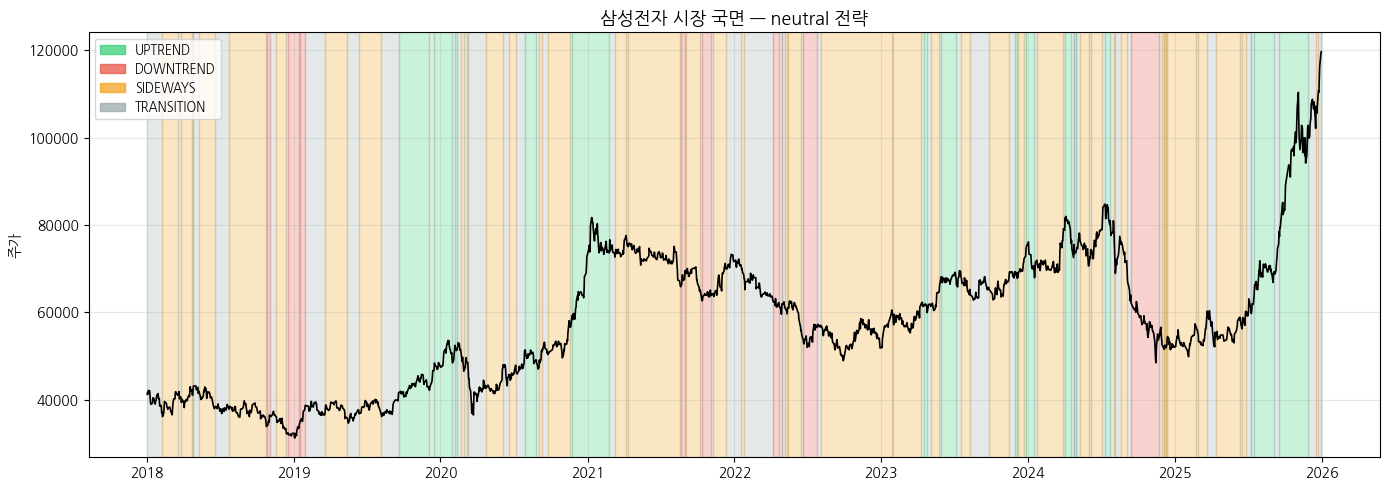


=== 국면 비율 ===
  UPTREND     :  312일  (15.9%)
  DOWNTREND   :  132일  (6.7%)
  SIDEWAYS    :  940일  (47.9%)
  TRANSITION  :  577일  (29.4%)


In [6]:
sample = names_stock[0]   # 삼성전자

_, _, _, detail = profile.make_signals(
    close_df[sample], high_df[sample], low_df[sample],
    adx_threshold=profile.ADX_THRESHOLD,
    adx_sideways=profile.ADX_SIDEWAYS,
    kospi=kospi,
)

plot_regime(
    close_df[sample],
    detail['regime'],
    title=f'{sample} 시장 국면 — {PROFILE_NAME} 전략',
)

---
## 6. Walk-Forward 백테스팅

### 6-1. Rotation 적용 (메인)

- **IS(In-Sample)**: 12개월 구간에서 종목별 독립 ADX 파라미터 그리드 서치
- **OOS(Out-of-Sample)**: 3개월 실전 적용
- **Rotation**: 편출 확정 종목은 IS 그리드 서치에서 제외, 매수 신호 차단

In [7]:
print('Walk-Forward 백테스팅 실행 중 (rotation 적용) ...')

pf_wf, wf_info = run_walk_forward(
    profile,
    close_df, high_df, low_df,
    kospi=kospi,
    cash_etf=cash_etf,
    init_cash=INITIAL_CAPITAL,
    rotation_plans=ROTATION_PLANS,   # ← Rotation 적용
)

first_test = wf_info['windows'][0]['test_start']
pf_bh = run_bh_portfolio(
    close_df[names_stock],   # B&H는 기존 5종목 기준
    start_date=first_test,
    fees=profile.FEES,
    slippage=profile.SLIPPAGE,
    init_cash=INITIAL_CAPITAL,
)

names_all = wf_info['names_all']   # 주식 전체 + 단기채

d    = extract(pf_wf)
d_bh = extract(pf_bh)

print(f'완료 — {wf_info["n_windows"]}개 WF 구간')

Walk-Forward 백테스팅 실행 중 (rotation 적용) ...
완료 — 27개 WF 구간


In [8]:
# WF 구간별 종목 파라미터 (rotation 반영)
rows = []
for i, w in enumerate(wf_info['windows'], 1):
    for name, sp in w['per_stock'].items():
        p  = sp['best_params']
        sc = sp['best_score']
        rows.append({
            '#':        i,
            'OOS 기간': f'{w["test_start"].date()} ~ {w["test_end"].date()}',
            '종목':     name,
            'adx_thr':  int(p.get('adx_threshold')),
            'adx_sw':   int(p.get('adx_sideways')),
            'IS score': round(sc, 3) if pd.notna(sc) else float('nan'),
            '모드':     'ADX' if sp['use_adx_mode'] else 'MA+KOSPI',
        })

pd.DataFrame(rows).set_index(['#', '종목'])

OOS 기간  adx_thr  adx_sw  IS score        모드
#  종목                                                                  
1  삼성전자    2019-01-02 ~ 2019-04-01       15      20     1.688       ADX
   SK하이닉스  2019-01-02 ~ 2019-04-01       15      10    -0.570  MA+KOSPI
   현대차     2019-01-02 ~ 2019-04-01       30      20    -0.451  MA+KOSPI
   NAVER   2019-01-02 ~ 2019-04-01       25      20    -0.669  MA+KOSPI
   KB금융    2019-01-02 ~ 2019-04-01       30      10    -0.186  MA+KOSPI
...                            ...      ...     ...       ...       ...
27 SK하이닉스  2025-07-02 ~ 2025-10-01       20      10     2.077       ADX
   현대차     2025-07-02 ~ 2025-10-01       15      20     3.311       ADX
   NAVER   2025-07-02 ~ 2025-10-01       20      10    -0.458  MA+KOSPI
   KB금융    2025-07-02 ~ 2025-10-01       15      20     1.831       ADX
   카카오     2025-07-02 ~ 2025-10-01       30      20     2.235       ADX

[154 rows x 5 columns]

### 6-2. Rotation 미적용 (비교 기준선)

동일 유니버스(6종목)로 rotation 없이 실행 — Section 9에서 비교에 사용

In [9]:
print('Walk-Forward 백테스팅 실행 중 (rotation 미적용, 비교용) ...')

pf_base, wf_base_info = run_walk_forward(
    profile,
    close_df, high_df, low_df,
    kospi=kospi,
    cash_etf=cash_etf,
    init_cash=INITIAL_CAPITAL,
    rotation_plans=None,   # ← Rotation 미적용
)

d_base = extract(pf_base)
print(f'완료 — {wf_base_info["n_windows"]}개 WF 구간')

Walk-Forward 백테스팅 실행 중 (rotation 미적용, 비교용) ...
완료 — 27개 WF 구간


---
## 7. 결과 분석

### Part 1 — 투자 잘한거야?

| 상태 | 의미 |
|------|------|
| ✓ | 목표 달성 |
| ⚠ | 경보선 이상, 목표 미달 |
| ✗ | 경보선 미달 |

#### 7-1. 성과 지표 테이블

In [10]:
tbl = build_metrics_table(
    d['equity'], close_df, profile,
    benchmark_series=kospi,
    etf_series=cash_etf,
)
print(f'=== {PROFILE_NAME} 전략 성과 지표 (Rotation 적용) [초기 자본: {INITIAL_CAPITAL:,}원] ===\n')
tbl

=== neutral 전략 성과 지표 (Rotation 적용) [초기 자본: 10,000,000원] ===



,neutral 전략,단기채 100%,KOSPI,목표,경보선,상태
지표,,,,,,
CAGR,18.56%,1.98%,11.17%,8.00%,5.00%,✓
MDD,-29.71%,-0.47%,-35.71%,-30.00%,-40.00%,✓
MDD기간(월),34.0,2.2,48.7,24.0,36.0,⚠
Calmar,0.62,4.26,0.31,0.35,0.20,✓
Sortino,1.37,4.03,0.88,0.80,0.50,✓
Alpha(vs KOSPI),+7.61%,—,—,+2.00%,+0.00%,✓
Beta,0.61,—,—,0.80,1.00,✓
MDD감소율(vs KOSPI),16.81%,—,—,20.00%,10.00%,⚠
Calmar개선,+0.32,—,—,+0.10,+0.00,✓


#### 7-2. 자산 곡선 비교 (전략 vs KOSPI vs 단기채)

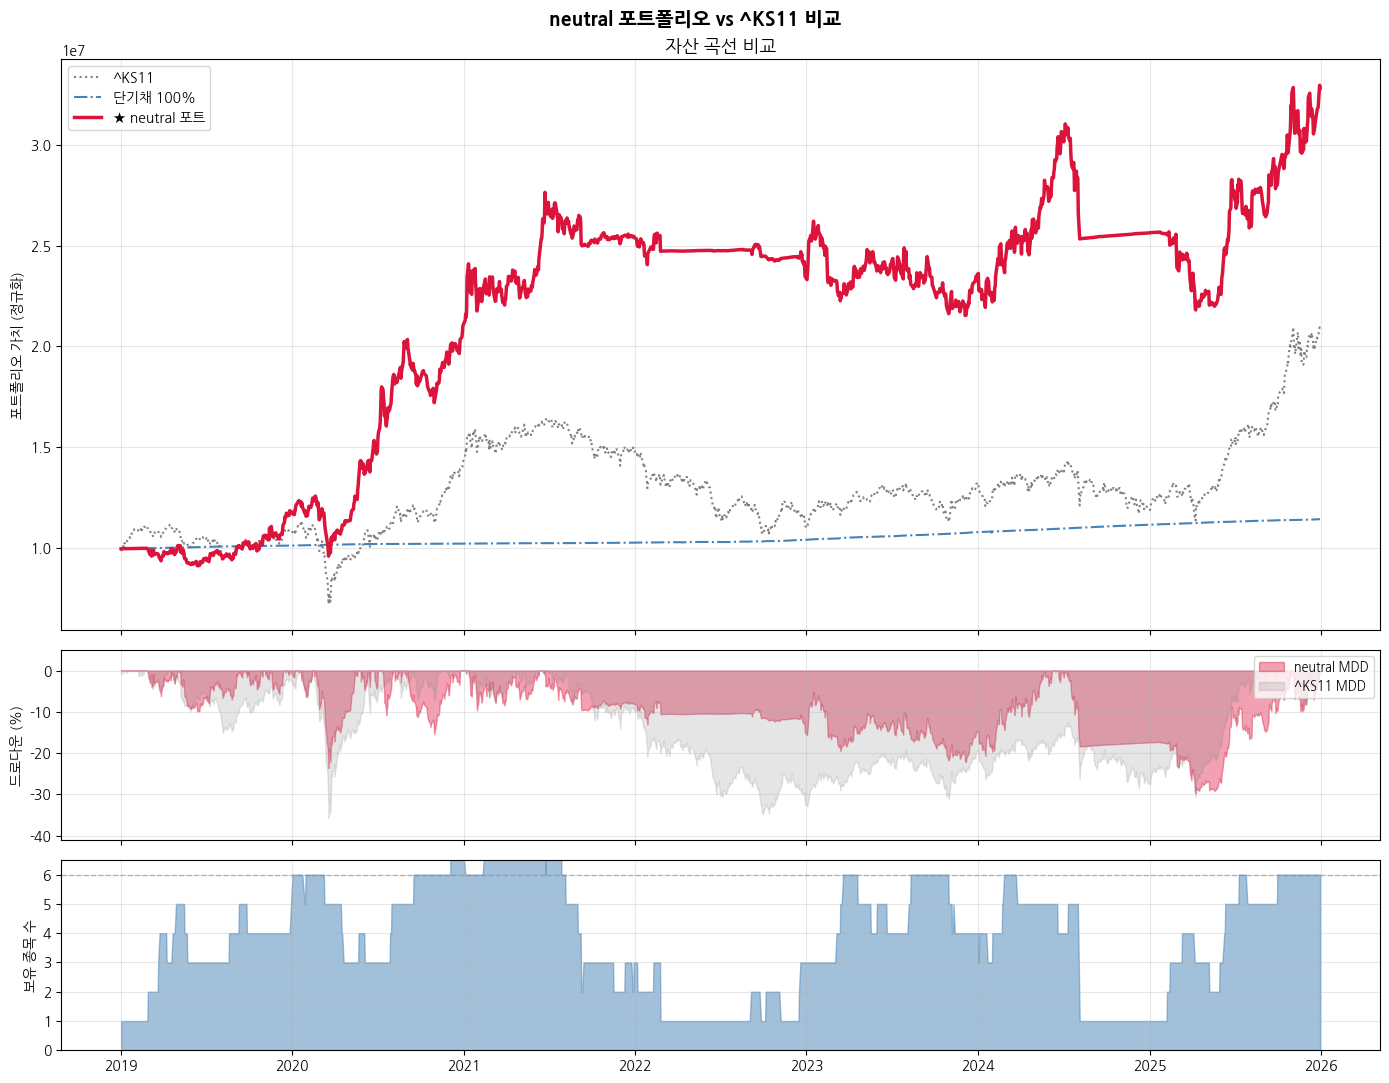

In [11]:
plot_equity_curves(
    d['equity'], d['asset_values'], names_all, n_universe,
    benchmark_series=kospi,
    etf_series=cash_etf,
    profile_name=PROFILE_NAME,
)

#### 7-3. MDD Depth + Duration 비교

=== MDD 비교 ===
  KOSPI (벤치마크)        : MDD 35.7%  Duration 1022일
  6종목 균등 B&H          : MDD 37.8%  Duration 657일
  neutral             : MDD 29.7%  Duration 713일

MDD depth: KOSPI -35.7% → neutral -29.7% (✅ 개선)


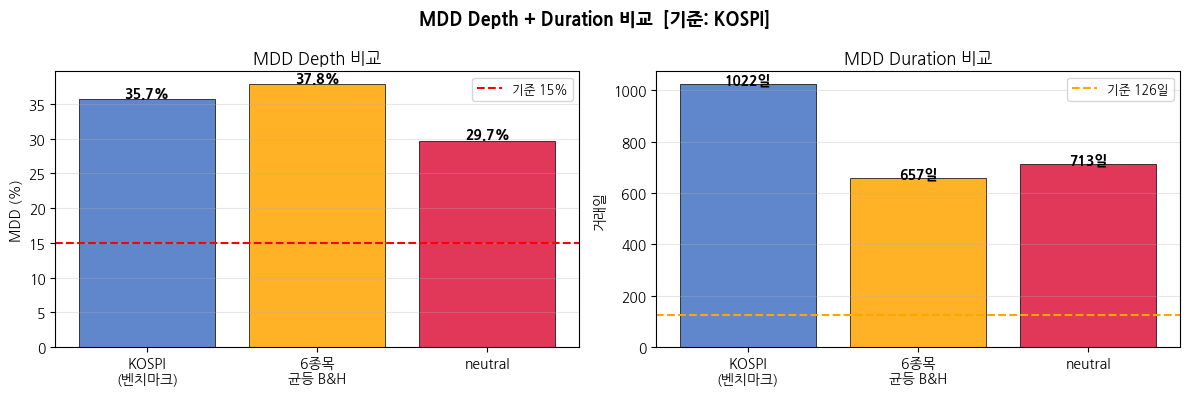

In [12]:
plot_mdd_comparison(
    d['equity'], d_bh['equity'], kospi,
    n=n_universe,
    profile_name=PROFILE_NAME,
)

---
### Part 2 — 어떻게 수익을 냈어?

#### 7-4. 월별 수익률 히트맵

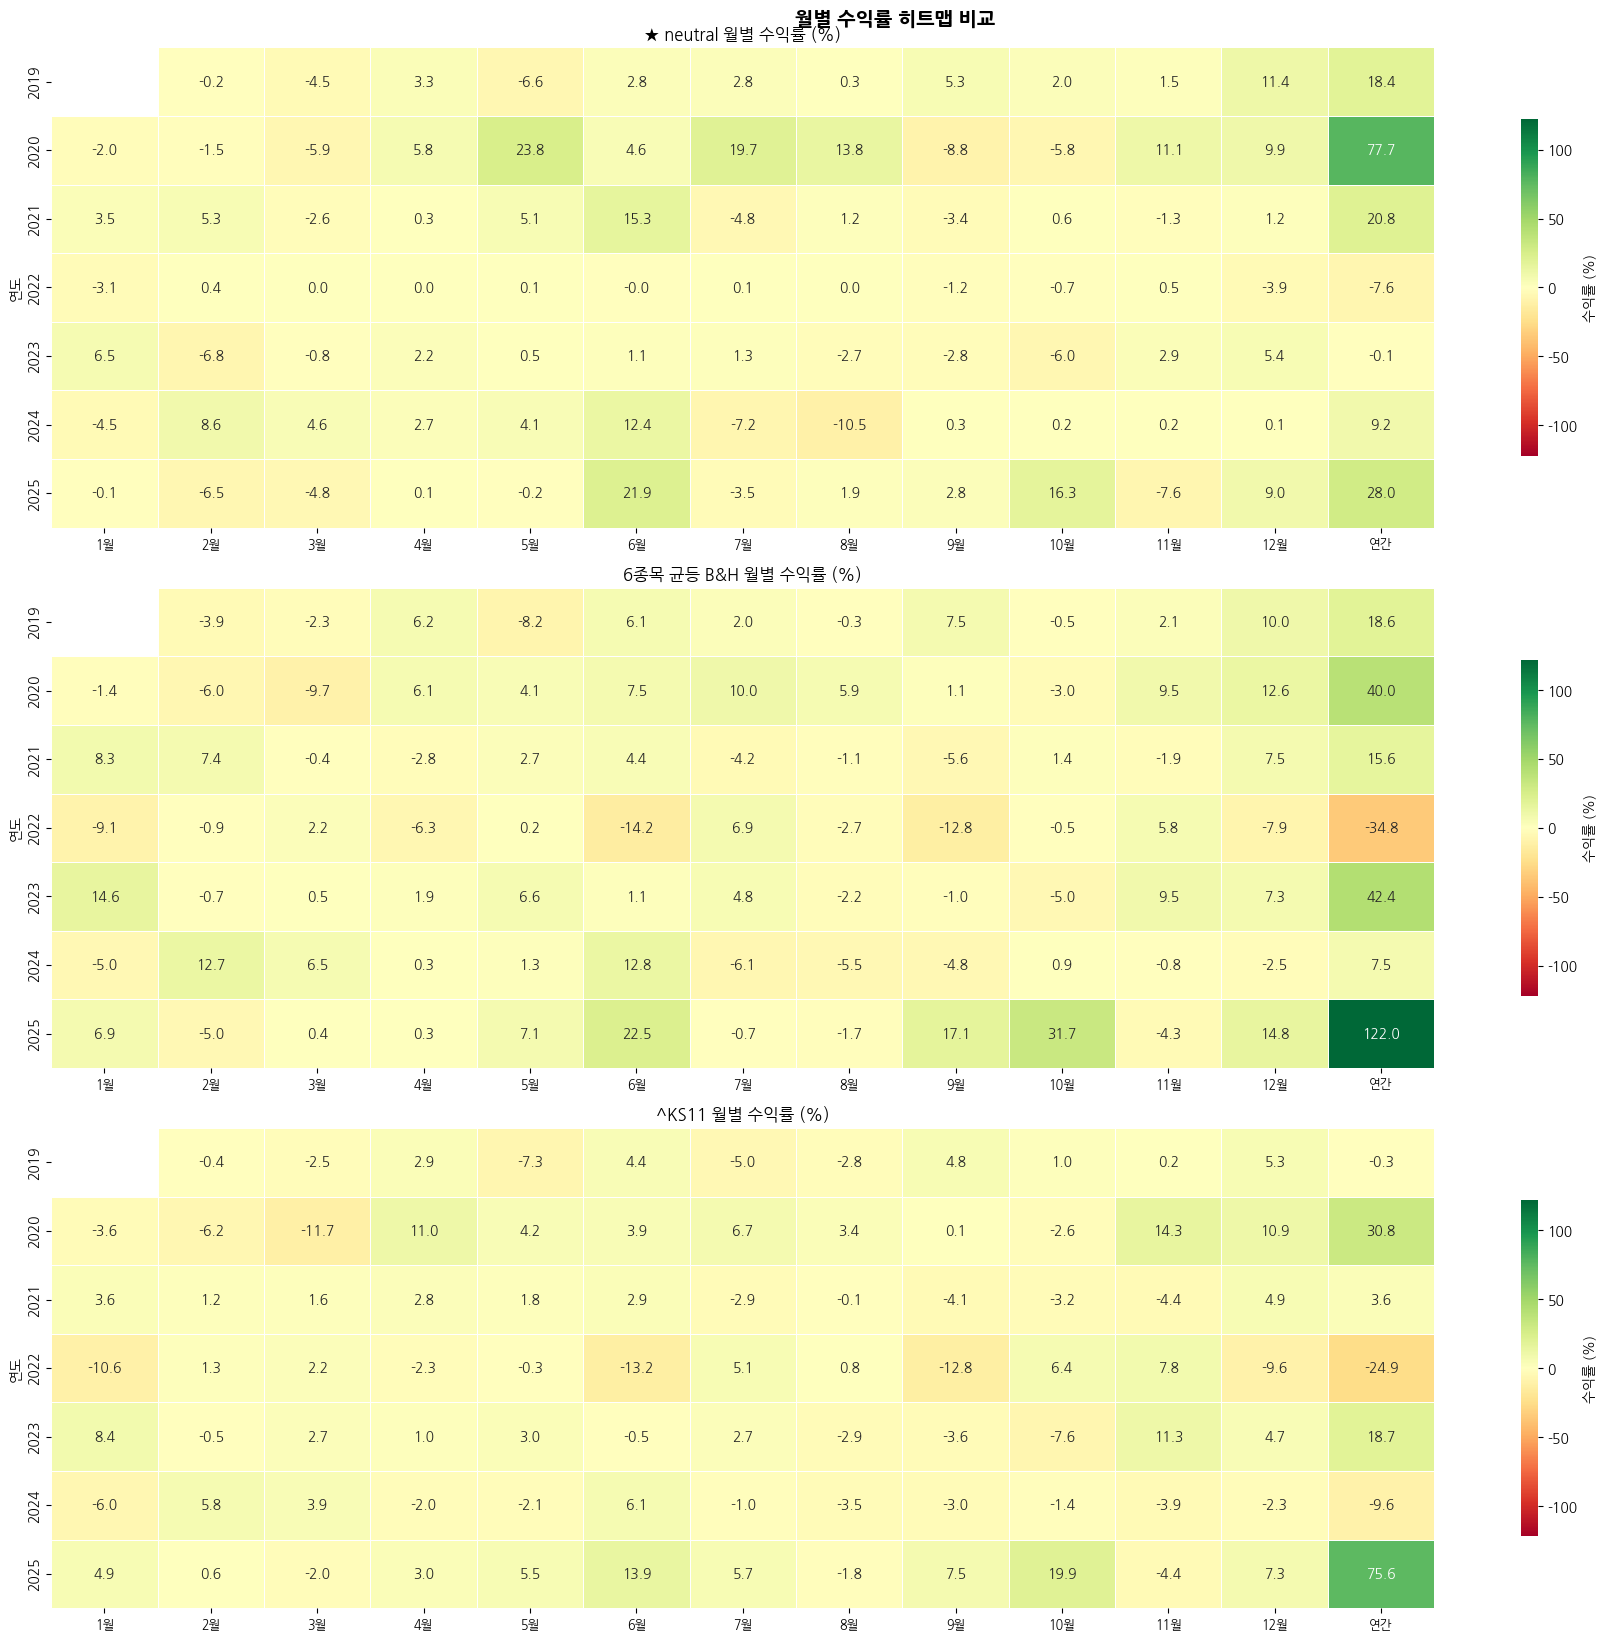

In [13]:
plot_monthly_heatmap(
    d['equity'], d_bh['equity'], n=n_universe,
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

#### 7-5. 연도별 수익률 비교

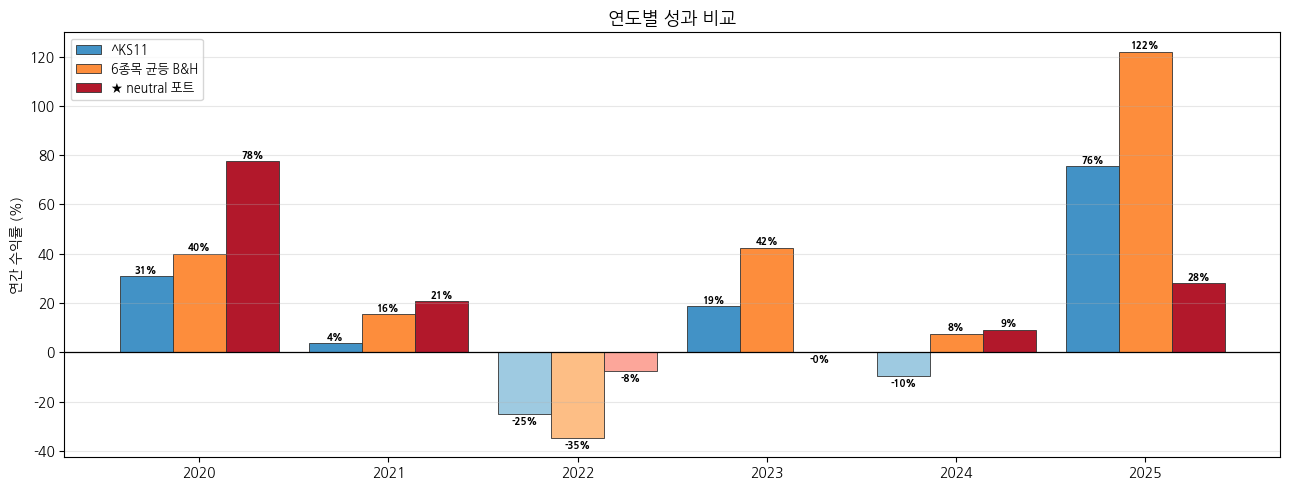

In [14]:
plot_yearly_returns(
    d['equity'], d_bh['equity'], n=n_universe,
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

#### 7-6. 분기별 수익률 비교

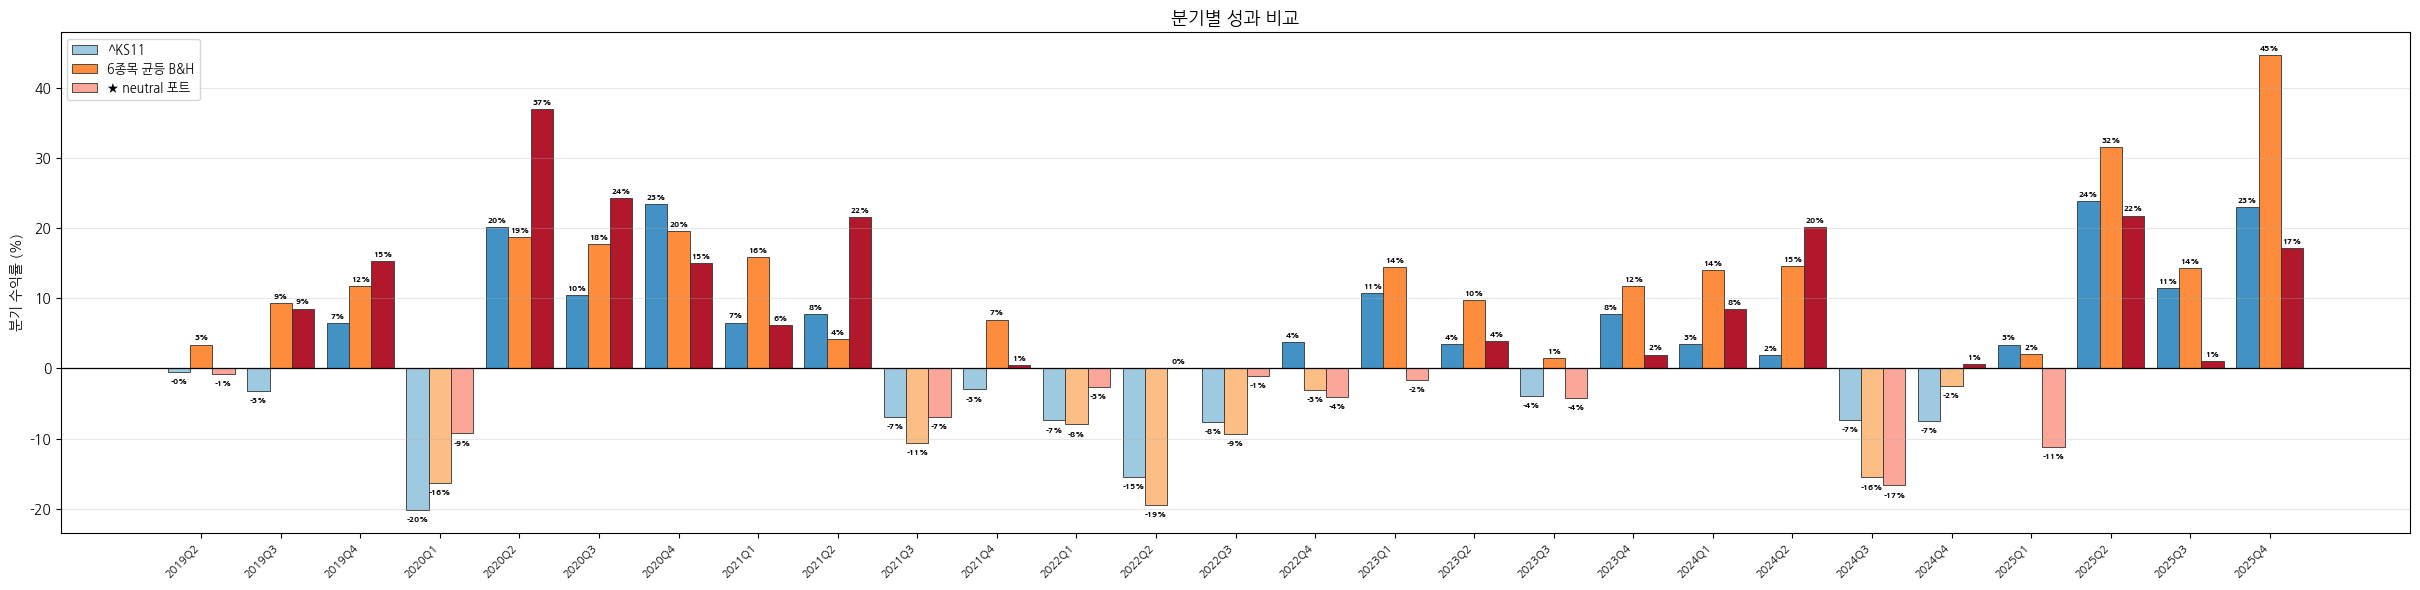

In [15]:
plot_quarterly_returns(
    d['equity'], d_bh['equity'], n=n_universe,
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

#### 7-7. 종목별 보유 비중 히트맵

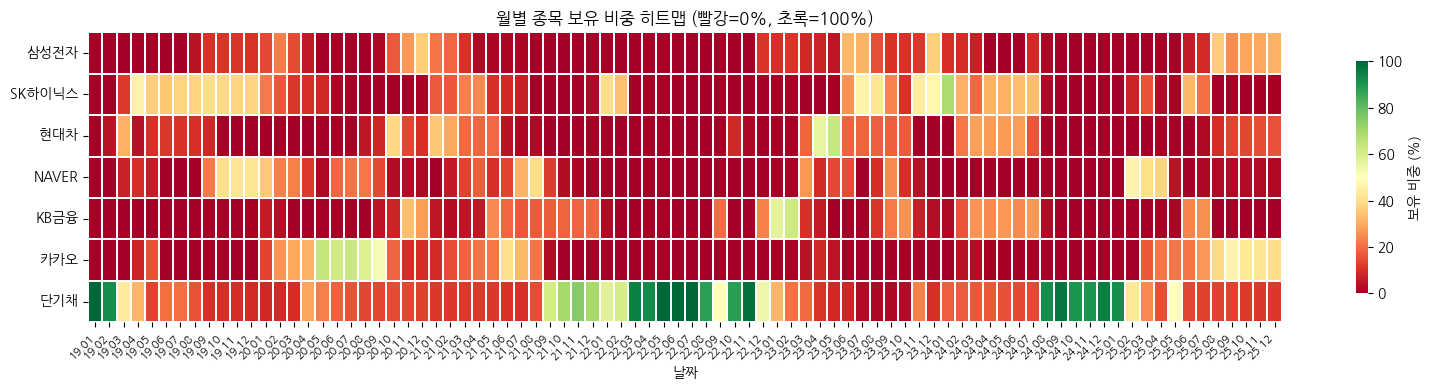


=== 종목별 평균 포지션 비중 ===
  삼성전자        : 7.6%  (최대 47.2%)
  SK하이닉스      : 14.1%  (최대 70.1%)
  현대차         : 8.8%  (최대 76.6%)
  NAVER       : 9.0%  (최대 70.0%)
  KB금융        : 8.3%  (최대 71.9%)
  카카오         : 11.9%  (최대 71.0%)
  단기채         : 34.7%  (최대 100.0%)


In [16]:
plot_weight_heatmap(d['equity'], d['asset_values'], names_all)

#### 7-8. 종목별 수익 기여도

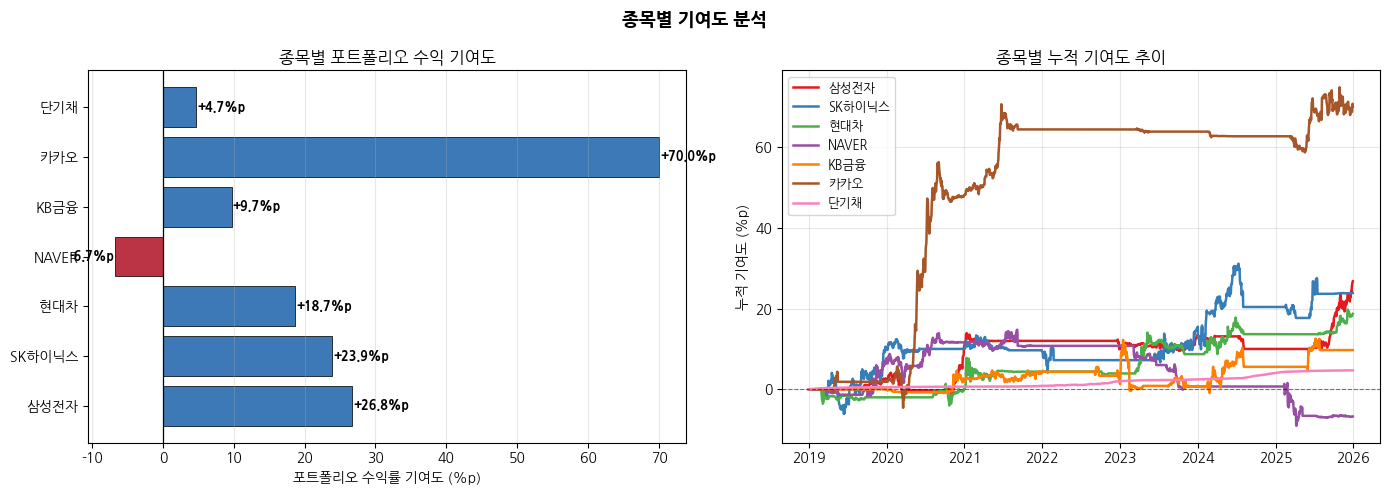

In [17]:
plot_contribution(d['equity'], d['asset_values'], wf_info['close_df_all'], names_all)

#### 7-9. 주식 vs 단기채 수익 기여도

    연도     주식 기여도      단기채 기여도     포트 총수익
--------------------------------------------
  2020    +46.99%       +16.68%     +77.70%
  2021     -6.81%       +27.50%     +20.84%
  2022    -11.45%        +5.43%      -7.57%
  2023    +41.55%       -38.02%      -0.05%
  2024    -75.39%       +78.89%      +9.22%
  2025   +115.76%       -76.85%     +28.02%


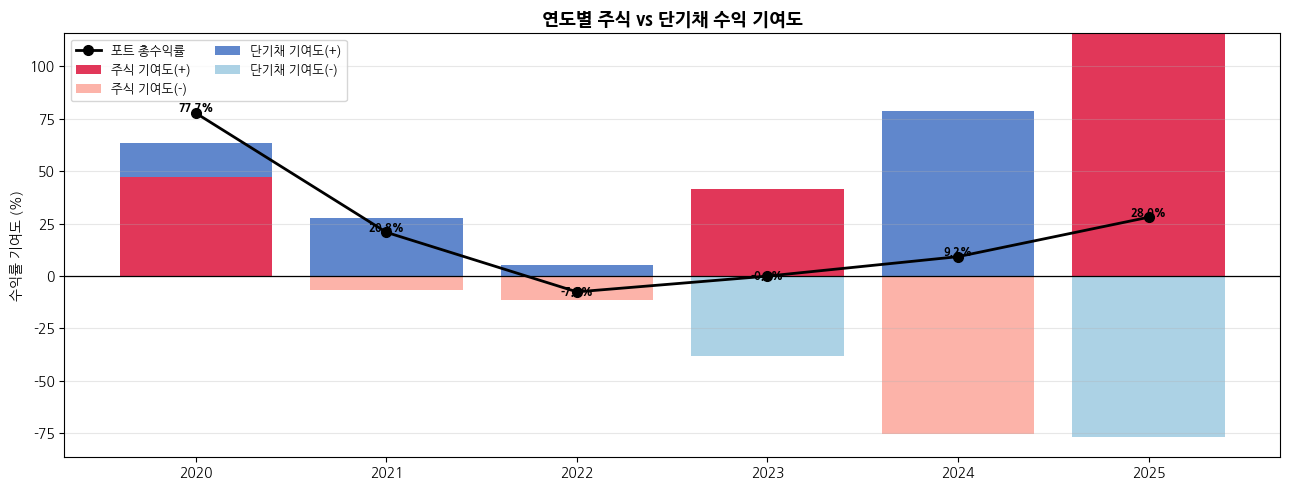

In [18]:
plot_yearly_stock_etf(d['equity'], d['asset_values'], names_all, etf_name=CASH_ETF_NAME)

---
## 8. Rotation 효과 분석

rotation 적용/미적용 비교를 통해 종목 교체 전략의 실질 효과를 측정한다.

### 8-1. 교체 일정 타임라인

In [19]:
print('=== 분기 종목 교체 일정 ===\n')
rows = []
for plan in ROTATION_PLANS:
    rows.append({
        '검토일':     plan.review_date,
        '편출 종목':  ', '.join(plan.exit_stocks),
        '편입 종목':  ', '.join(plan.entry_stocks),
        '마감 거래일': plan.deadline_days,
    })
pd.DataFrame(rows).set_index('검토일')

=== 분기 종목 교체 일정 ===



,편출 종목,편입 종목,마감 거래일
검토일,,,
2022-01-03,NAVER,카카오,20
2024-01-02,카카오,NAVER,20


### 8-2. WF 구간별 Active 종목 변화

In [20]:
rows = []
for i, w in enumerate(wf_info['windows'], 1):
    active  = sorted(w['per_stock'].keys())
    exited  = [n for n in all_names if n not in active]
    rows.append({
        '#':         i,
        'OOS 시작':  str(w['test_start'].date()),
        'OOS 종료':  str(w['test_end'].date()),
        'Active 종목': ', '.join(active),
        '제외(sell-only)': ', '.join(exited) if exited else '-',
    })

df_win = pd.DataFrame(rows).set_index('#')

# 종목 변화가 있는 구간 하이라이트
changed = df_win['제외(sell-only)'] != '-'
if changed.any():
    print(f'⚠ 종목 교체가 반영된 구간 ({changed.sum()}개):\n')
    display(df_win[changed])
    print(f'\n전체 {len(df_win)}개 구간 중 {changed.sum()}개에서 종목 제외 발생')
else:
    print('종목 교체 없음')
    display(df_win)

⚠ 종목 교체가 반영된 구간 (8개):



,OOS 시작,OOS 종료,Active 종목,제외(sell-only)
#,,,,
14,2022-04-04,2022-07-01,"KB금융, SK하이닉스, 삼성전자, 카카오, 현대차",NAVER
15,2022-07-04,2022-09-30,"KB금융, SK하이닉스, 삼성전자, 카카오, 현대차",NAVER
16,2022-10-04,2022-12-29,"KB금융, SK하이닉스, 삼성전자, 카카오, 현대차",NAVER
17,2023-01-02,2023-03-31,"KB금융, SK하이닉스, 삼성전자, 카카오, 현대차",NAVER
22,2024-04-02,2024-07-01,"KB금융, NAVER, SK하이닉스, 삼성전자, 현대차",카카오
23,2024-07-02,2024-09-30,"KB금융, NAVER, SK하이닉스, 삼성전자, 현대차",카카오
24,2024-10-02,2024-12-30,"KB금융, NAVER, SK하이닉스, 삼성전자, 현대차",카카오
25,2025-01-02,2025-04-01,"KB금융, NAVER, SK하이닉스, 삼성전자, 현대차",카카오



전체 27개 구간 중 8개에서 종목 제외 발생


### 8-3. Rotation 적용 vs 미적용 — 자산 곡선 비교

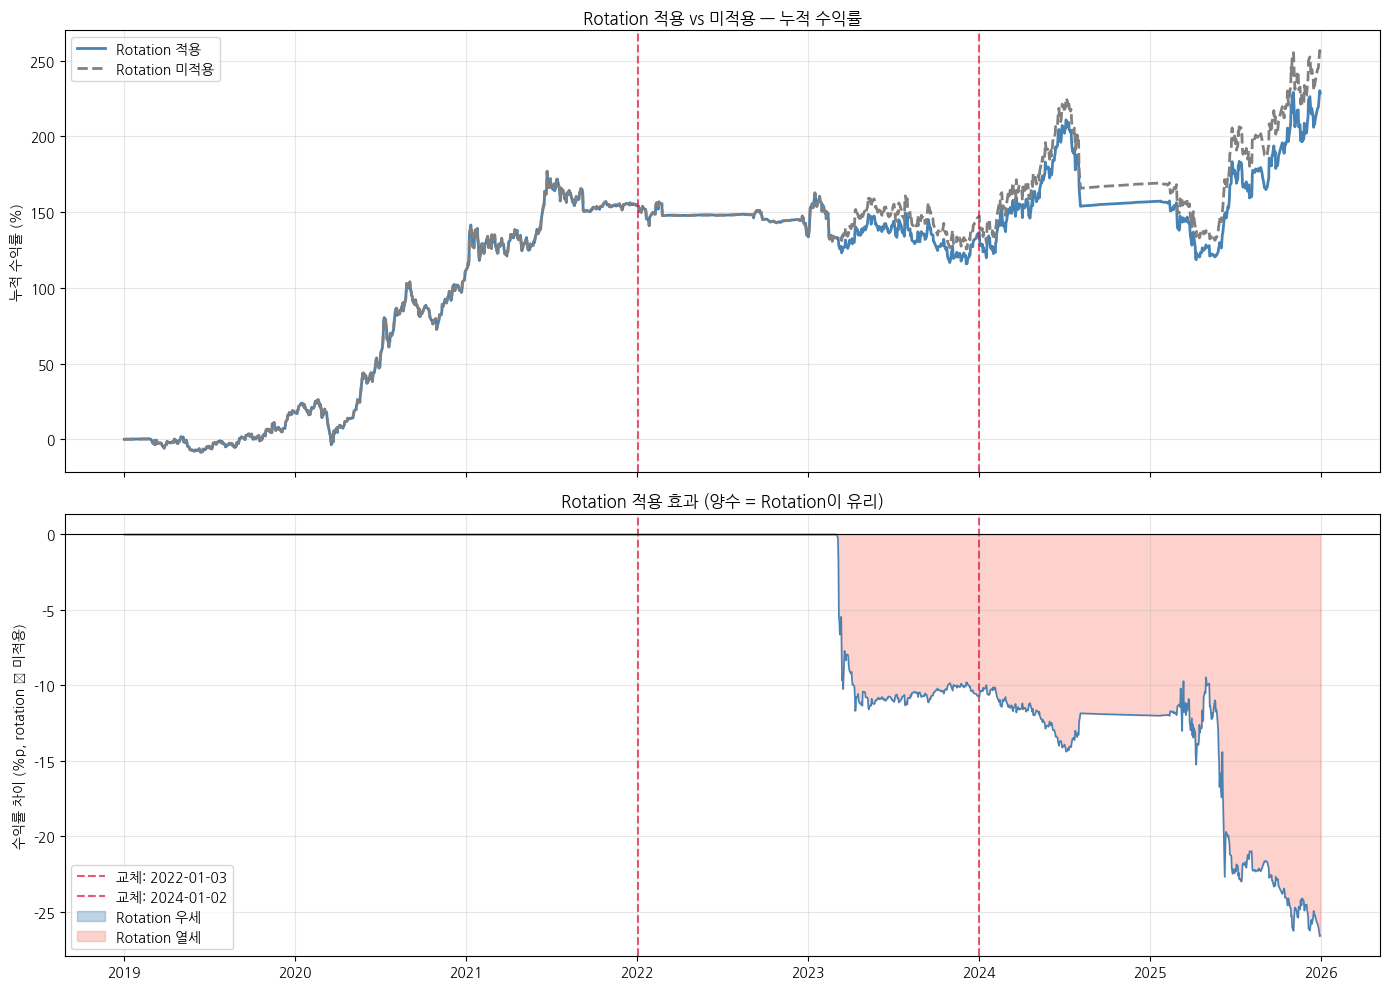

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

eq_rot  = d['equity']
eq_base = d_base['equity']
start   = max(eq_rot.index[0], eq_base.index[0])
er = (eq_rot[eq_rot.index >= start]   / eq_rot[eq_rot.index >= start].iloc[0]   - 1) * 100
eb = (eq_base[eq_base.index >= start] / eq_base[eq_base.index >= start].iloc[0] - 1) * 100

# 상단: 누적 수익률
ax = axes[0]
ax.plot(er.index, er, label='Rotation 적용',   color='steelblue', lw=2)
ax.plot(eb.index, eb, label='Rotation 미적용', color='gray',      lw=2, linestyle='--')
ax.set_ylabel('누적 수익률 (%)')
ax.set_title('Rotation 적용 vs 미적용 — 누적 수익률')
ax.legend()
ax.grid(True, alpha=0.3)

# 교체 시점 수직선
for plan in ROTATION_PLANS:
    dt = pd.Timestamp(plan.review_date)
    for a in axes:
        if eq_rot.index[0] <= dt <= eq_rot.index[-1]:
            a.axvline(dt, color='crimson', alpha=0.7, linestyle='--', lw=1.5,
                      label=f'교체: {plan.review_date}')

# 하단: 수익률 차이
ax2 = axes[1]
diff = er - eb.reindex(er.index, method='ffill')
ax2.fill_between(diff.index, diff, 0, where=(diff >= 0),
                 color='steelblue', alpha=0.35, label='Rotation 우세')
ax2.fill_between(diff.index, diff, 0, where=(diff < 0),
                 color='salmon',    alpha=0.35, label='Rotation 열세')
ax2.plot(diff.index, diff, color='steelblue', lw=1.2)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('수익률 차이 (%p, rotation − 미적용)')
ax2.set_title('Rotation 적용 효과 (양수 = Rotation이 유리)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8-4. Rotation 전후 성과 비교 테이블

In [22]:
m_rot  = calc_metrics(d['equity'],      benchmark_series=kospi)
m_base = calc_metrics(d_base['equity'], benchmark_series=kospi)

labels = {
    'cagr':               ('CAGR',          '{:.2%}'),
    'mdd':                ('MDD',           '{:.2%}'),
    'mdd_duration':       ('MDD기간(월)',    '{:.1f}'),
    'calmar':             ('Calmar',        '{:.2f}'),
    'sortino':            ('Sortino',       '{:.2f}'),
    'alpha':              ('Alpha(vs KOSPI)', '{:+.2%}'),
    'beta':               ('Beta',          '{:.2f}'),
    'mdd_reduction':      ('MDD감소율',     '{:.2%}'),
    'calmar_improvement': ('Calmar개선',    '{:+.2f}'),
    'info_ratio':         ('IR(vs KOSPI)',  '{:.2f}'),
    'win_rate':           ('승률',          '{:.2%}'),
}

rows = []
for key, (label, fmt) in labels.items():
    vr = m_rot.get(key,  float('nan'))
    vb = m_base.get(key, float('nan'))
    try:
        str_r, str_b = fmt.format(vr), fmt.format(vb)
    except Exception:
        str_r, str_b = 'N/A', 'N/A'
    rows.append({'지표': label, 'Rotation 적용': str_r, 'Rotation 미적용': str_b})

df_cmp = pd.DataFrame(rows).set_index('지표')
print('=== Rotation 적용 vs 미적용 성과 비교 ===\n')
df_cmp

=== Rotation 적용 vs 미적용 성과 비교 ===



,Rotation 적용,Rotation 미적용
지표,,
CAGR,18.56%,19.88%
MDD,-29.71%,-28.87%
MDD기간(월),34.0,33.6
Calmar,0.62,0.69
Sortino,1.37,1.46
Alpha(vs KOSPI),+7.61%,+8.98%
Beta,0.61,0.60
MDD감소율,16.81%,19.14%
Calmar개선,+0.32,+0.39


### 8-5. 교체 종목 가격 추이 (편출 전후)

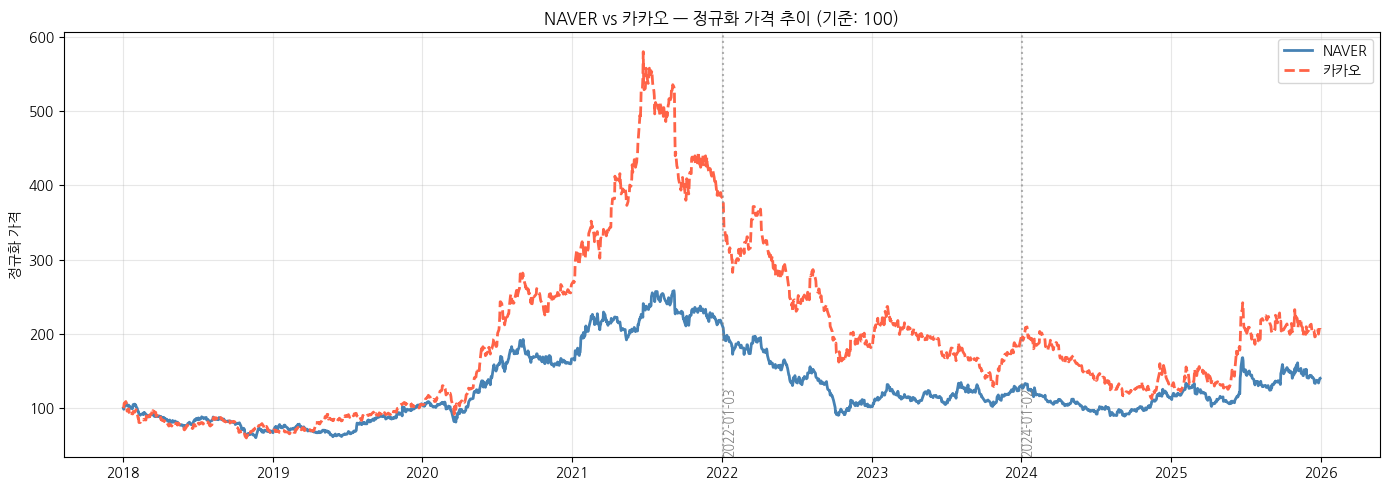

In [23]:
# NAVER vs 카카오 정규화 가격 비교 (rotation 검토일 기준)
fig, ax = plt.subplots(figsize=(14, 5))

for name, color, ls in [('NAVER', 'steelblue', '-'), ('카카오', 'tomato', '--')]:
    if name in close_df.columns:
        s = close_df[name].dropna()
        norm = s / s.iloc[0] * 100
        ax.plot(norm.index, norm, label=name, color=color, linestyle=ls, lw=2)

# 교체 시점 수직선
for plan in ROTATION_PLANS:
    dt = pd.Timestamp(plan.review_date)
    ax.axvline(dt, color='gray', alpha=0.6, linestyle=':', lw=1.5)
    ax.text(dt, ax.get_ylim()[0] * 1.02 if ax.get_ylim()[0] > 0 else 10,
            plan.review_date, rotation=90, fontsize=9, color='gray', va='bottom')

ax.set_title('NAVER vs 카카오 — 정규화 가격 추이 (기준: 100)')
ax.set_ylabel('정규화 가격')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. 기간별 수익률 상세 테이블

In [24]:
tbl_yearly = build_period_stats_table(
    d['equity'], d_bh['equity'],
    benchmark_series=kospi,
    freq='Y',
    profile_name=PROFILE_NAME,
)
print('=== 연도별 수익률 비교 ===\n')
tbl_yearly

=== 연도별 수익률 비교 ===



,neutral(%),B&H(%),KOSPI(%),neutral-KOSPI(%p),neutral-B&H(%p)
2020,77.70,39.99,30.75,46.95,37.71
2021,20.84,15.55,3.63,17.21,5.29
2022,-7.57,-34.78,-24.89,17.32,27.21
2023,-0.05,42.42,18.73,-18.78,-42.47
2024,9.22,7.51,-9.63,18.85,1.71
2025,28.02,121.96,75.63,-47.60,-93.94


In [25]:
tbl_quarterly = build_period_stats_table(
    d['equity'], d_bh['equity'],
    benchmark_series=kospi,
    freq='Q',
    profile_name=PROFILE_NAME,
)
print('=== 분기별 수익률 비교 ===\n')
tbl_quarterly

=== 분기별 수익률 비교 ===



,neutral(%),B&H(%),KOSPI(%),neutral-KOSPI(%p),neutral-B&H(%p)
2019Q2,-0.79,3.40,-0.47,-0.32,-4.18
2019Q3,8.54,9.27,-3.17,11.71,-0.74
2019Q4,15.34,11.76,6.53,8.81,3.57
2020Q1,-9.24,-16.29,-20.16,10.92,7.05
2020Q2,37.00,18.74,20.16,16.84,18.27
2020Q3,24.23,17.76,10.41,13.82,6.47
2020Q4,15.03,19.60,23.44,-8.40,-4.57
2021Q1,6.20,15.91,6.54,-0.34,-9.71
2021Q2,21.58,4.22,7.68,13.90,17.36
2021Q3,-6.90,-10.57,-6.91,0.01,3.67


---
## 부록 — 참고용

### A-1. 종목별 단독 B&H 비교

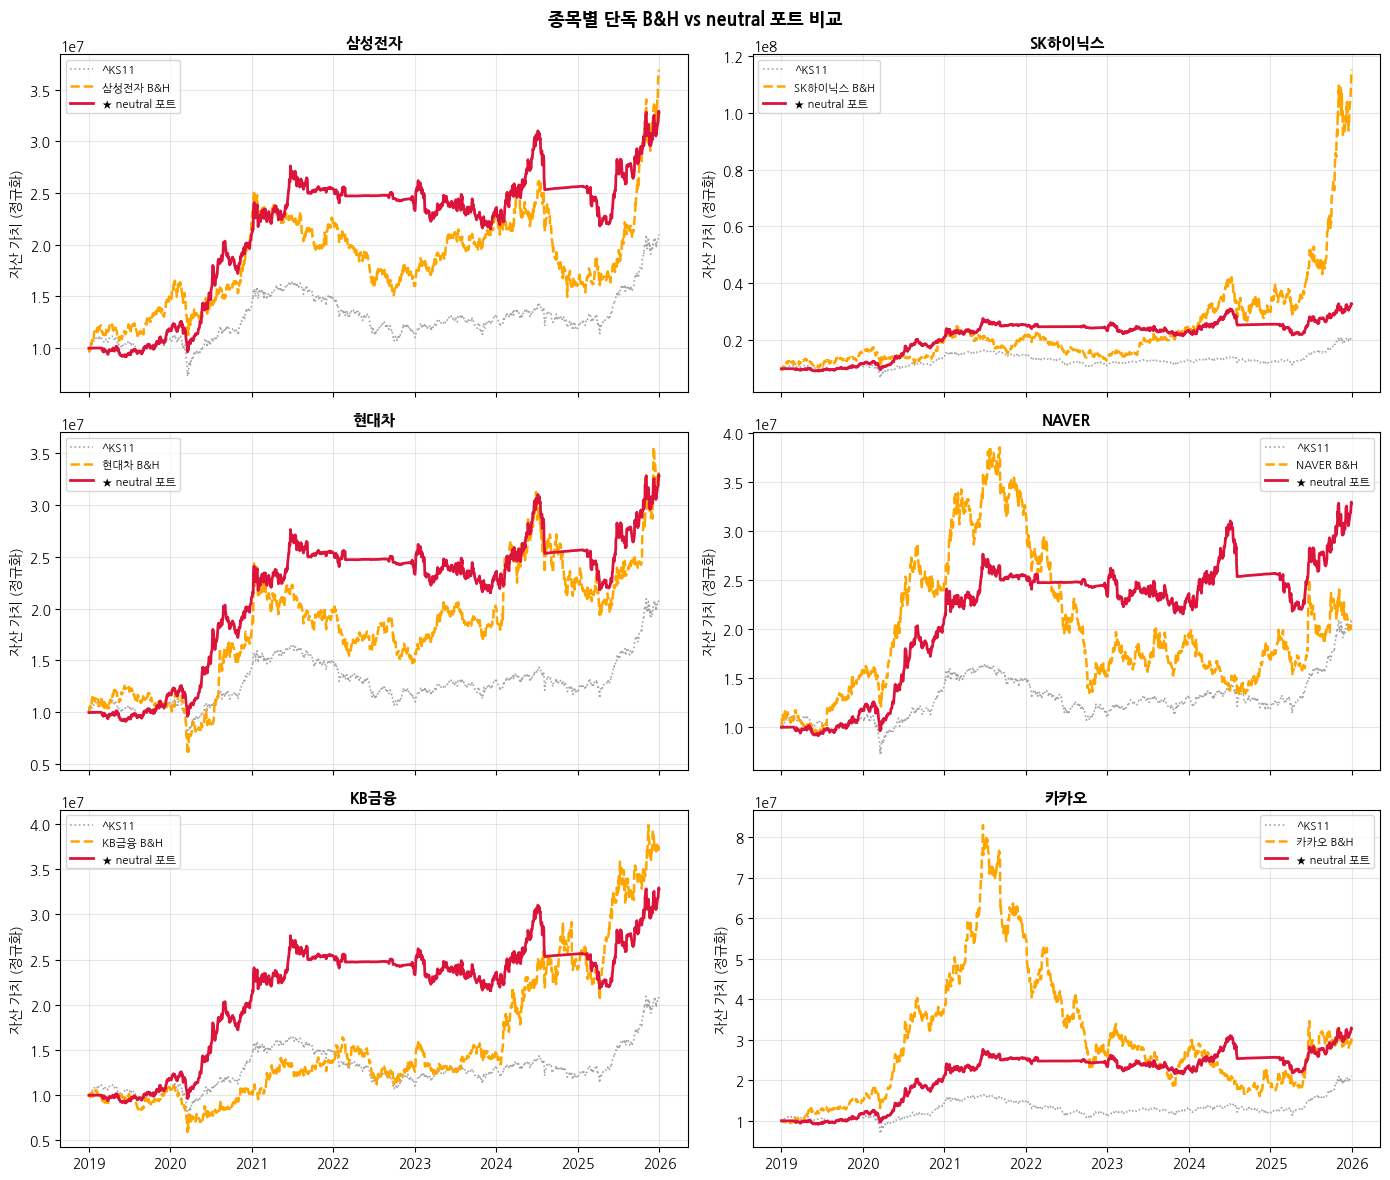

In [26]:
plot_per_stock_equity_curves(
    d['equity'], close_df, all_names,
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### A-2. 연도별 실제 손익 (원화 기준)

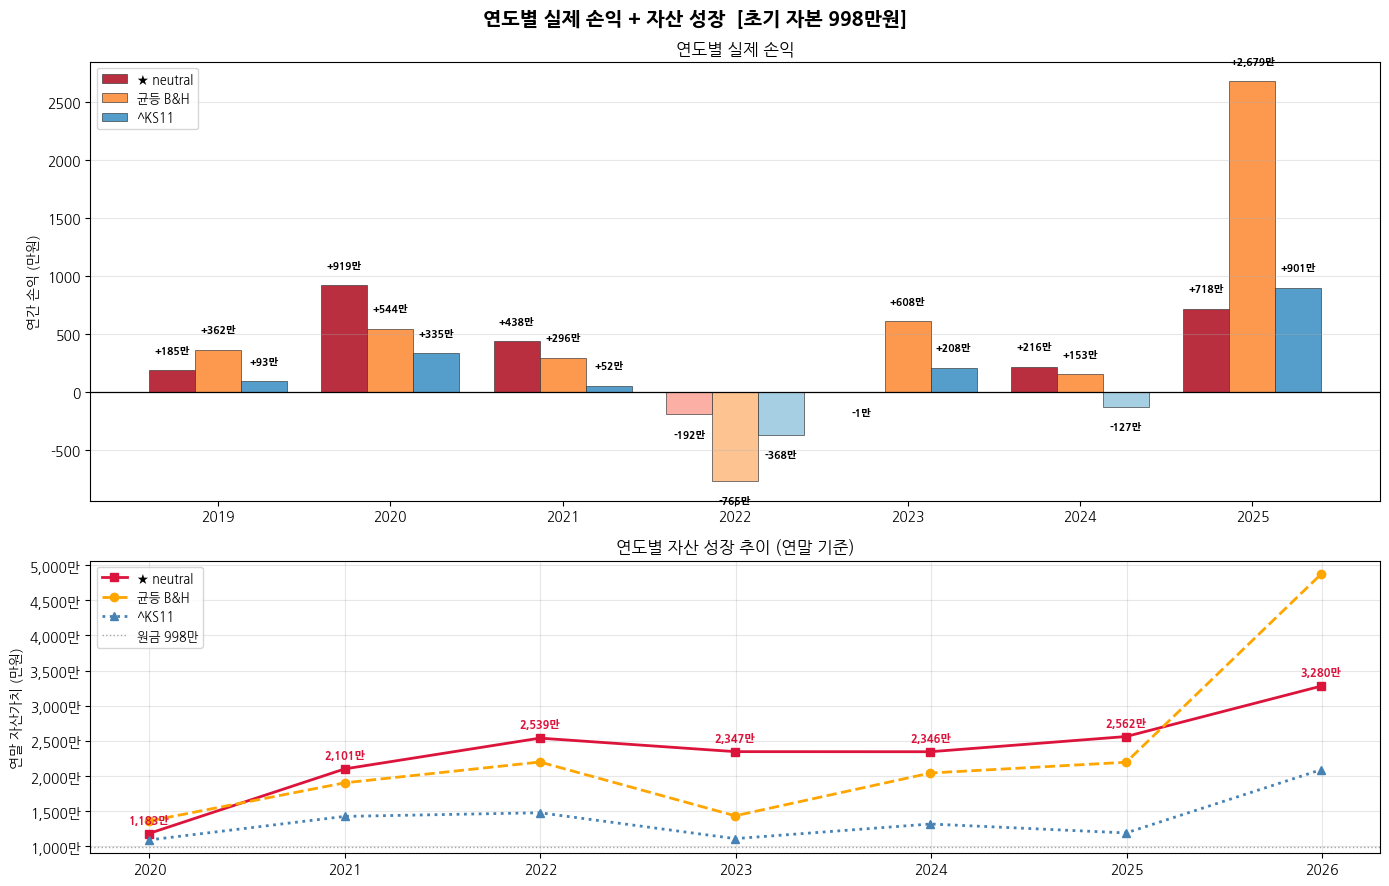


초기 자본: 998만원

  연도      전략 잔고      전략 손익     B&H 잔고     B&H 손익
----------------------------------------------------
2019    1,183만      +185만    1,360만      +362만
2020    2,101만      +919만    1,904만      +544만
2021    2,539만      +438만    2,200만      +296만
2022    2,347만      -192만    1,435만      -765만
2023    2,346만        -1만    2,043만      +608만
2024    2,562만      +216만    2,196만      +153만
2025    3,280만      +718만    4,875만    +2,679만

  ■ 최종 잔고: 3,280만원  ■ 총 손익: +2,283만  ■ 수익 연도: 5/7


In [27]:
plot_yearly_pnl(
    d['equity'], d_bh['equity'],
    benchmark_series=kospi,
    profile_name=PROFILE_NAME,
)

### A-3. 분산투자 효과 (상관관계 + 변동성)

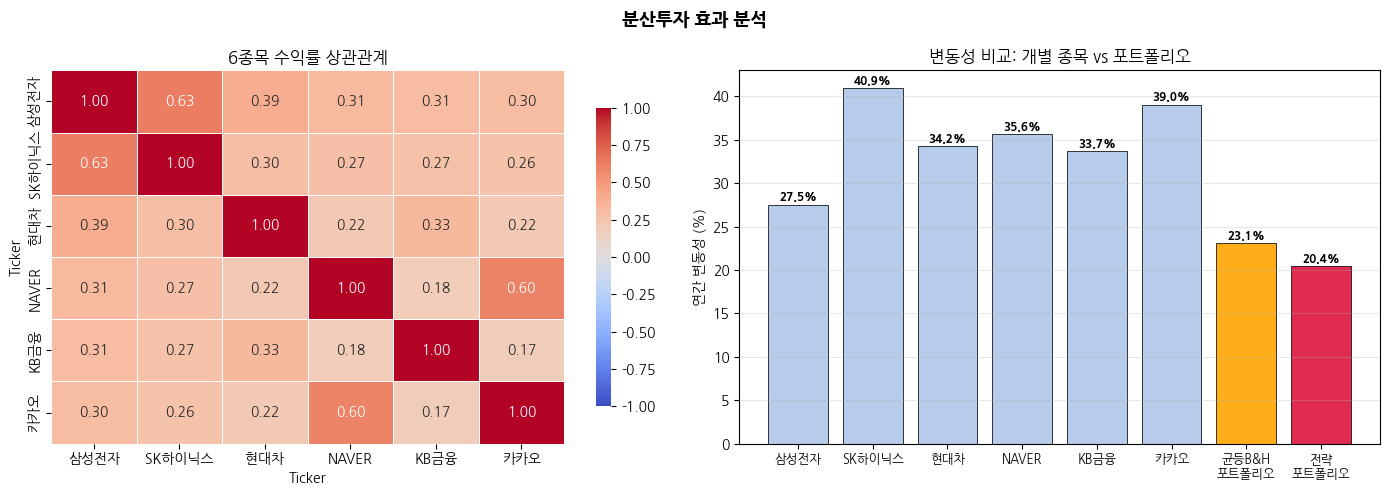

In [28]:
plot_diversification(d['equity'], close_df, all_names)